# Data Loading & Quality

## 1.1 Import Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/saas_50k_v1.csv")
df.shape

(1150000, 16)

## 1.2 Data Describe

In [2]:
df.head()

,account_id,month,company_size,industry,contract_type,discount_pct,regime_state,active_users,usage_growth,feature_adoption_rate,error_rate,tickets_count,ticket_growth,payment_delay_flag,current_mrr,next_month_mrr
0,0,1,SMB,Energy,Monthly,0.054167,stable,4.765884,0.017574,0.002766,0.102689,0.0,0.0,0,112.703497,50.000000
1,0,2,SMB,Energy,Monthly,0.054167,stable,11.706351,0.027244,0.000000,0.102174,2.0,inf,1,50.000000,51.903945
2,0,3,SMB,Energy,Monthly,0.054167,decline,12.706351,0.004655,0.082195,0.195298,2.0,0.0,0,51.903945,50.000000
3,0,4,SMB,Energy,Monthly,0.054167,decline,17.393579,-0.024496,0.062898,0.104958,3.0,0.5,1,50.000000,55.680067
4,0,5,SMB,Energy,Monthly,0.054167,decline,20.607523,-0.073376,0.120356,0.076803,0.0,-1.0,0,55.680067,50.000000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1150000 entries, 0 to 1149999
Data columns (total 16 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   account_id             1150000 non-null  int64  
 1   month                  1150000 non-null  int64  
 2   company_size           1150000 non-null  str    
 3   industry               1150000 non-null  str    
 4   contract_type          1150000 non-null  str    
 5   discount_pct           1034760 non-null  float64
 6   regime_state           1150000 non-null  str    
 7   active_users           1150000 non-null  float64
 8   usage_growth           1150000 non-null  float64
 9   feature_adoption_rate  1115624 non-null  float64
 10  error_rate             1133821 non-null  float64
 11  tickets_count          1127186 non-null  float64
 12  ticket_growth          1150000 non-null  float64
 13  payment_delay_flag     1150000 non-null  int64  
 14  current_mrr            115000

In [4]:
df.nunique()

account_id                 50000
month                         23
company_size                   3
industry                      10
contract_type                  2
discount_pct               50000
regime_state                   3
active_users             1145882
usage_growth             1150000
feature_adoption_rate    1023028
error_rate               1133821
tickets_count                 42
ticket_growth                576
payment_delay_flag             2
current_mrr               888733
next_month_mrr            881418
dtype: int64

In [6]:
overview = pd.DataFrame({
    "dtype": df.dtypes,
    "unique_values": df.nunique(),
    "missing_values": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
})

print(overview)

                         dtype  unique_values  missing_values  missing_pct
account_id               int64          50000               0     0.000000
month                    int64             23               0     0.000000
company_size               str              3               0     0.000000
industry                   str             10               0     0.000000
contract_type              str              2               0     0.000000
discount_pct           float64          50000          115240    10.020870
regime_state               str              3               0     0.000000
active_users           float64        1145882               0     0.000000
usage_growth           float64        1150000               0     0.000000
feature_adoption_rate  float64        1023028           34376     2.989217
error_rate             float64        1133821           16179     1.406870
tickets_count          float64             42           22814     1.983826
ticket_growth          fl

## 1.3 Data Types

In [7]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "string"]).columns

print("Numerical columns:")
print(list(numeric_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numerical columns:
['account_id', 'month', 'discount_pct', 'active_users', 'usage_growth', 'feature_adoption_rate', 'error_rate', 'tickets_count', 'ticket_growth', 'payment_delay_flag', 'current_mrr', 'next_month_mrr']

Categorical columns:
['company_size', 'industry', 'contract_type', 'regime_state']


## 1.4 Duplicates

In [9]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [10]:
account_month_duplicates = df.duplicated(subset=["account_id", "month"]).sum()
print("Duplicate account-month records:", account_month_duplicates)

Duplicate account-month records: 0


## 1.5 Invalid Values

In [11]:
checks = {
    "discount_pct < 0": (df["discount_pct"] < 0).sum(),
    "discount_pct > 100": (df["discount_pct"] > 100).sum(),

    "feature_adoption_rate < 0": (df["feature_adoption_rate"] < 0).sum(),
    "feature_adoption_rate > 1": (df["feature_adoption_rate"] > 1).sum(),

    "error_rate < 0": (df["error_rate"] < 0).sum(),
    "error_rate > 1": (df["error_rate"] > 1).sum(),

    "active_users < 0": (df["active_users"] < 0).sum(),
    "tickets_count < 0": (df["tickets_count"] < 0).sum(),

    "current_mrr < 0": (df["current_mrr"] < 0).sum(),
    "next_month_mrr < 0": (df["next_month_mrr"] < 0).sum()
}

pd.Series(checks)

discount_pct < 0             0
discount_pct > 100           0
feature_adoption_rate < 0    0
feature_adoption_rate > 1    0
error_rate < 0               0
error_rate > 1               0
active_users < 0             0
tickets_count < 0            0
current_mrr < 0              0
next_month_mrr < 0           0
dtype: int64

In [12]:
df[[
    "usage_growth",
    "ticket_growth",
    "discount_pct",
    "feature_adoption_rate",
    "error_rate"
]].describe().T

/home/youssef/ml_env/lib/python3.12/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
usage_growth,1150000.0,0.012803,0.036889,-0.149102,-0.012028,0.014375,0.038819,0.168098
ticket_growth,1150000.0,inf,NaN,-1.000000,-0.300000,0.000000,0.750000,inf
discount_pct,1034760.0,0.058306,0.036116,0.000285,0.030653,0.051782,0.079194,0.252599
feature_adoption_rate,1115624.0,0.500057,0.339723,0.000000,0.165016,0.499969,0.835096,1.000000
error_rate,1133821.0,0.103018,0.067043,0.000073,0.052176,0.089969,0.139840,0.646128


In [16]:
for col in categorical_cols:
    print("\n" + str(df[col].value_counts(dropna=False)))


company_size
SMB           691127
Mid           344402
Enterprise    114471
Name: count, dtype: int64

industry
Consulting       116679
SaaS             115874
EdTech           115598
Energy           115253
Health           115184
Logistics        115092
Media            114885
Fintech          114563
Retail           113597
Manufacturing    113275
Name: count, dtype: int64

contract_type
Monthly    1064762
Annual       85238
Name: count, dtype: int64

regime_state
stable     506686
growth     413980
decline    229334
Name: count, dtype: int64


# Missing Values

## 2.1 Check Missingness Changes

In [17]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
})

missing = missing[missing["missing_count"] > 0].sort_values(
    "missing_pct",
    ascending=False
)

print(missing)

                       missing_count  missing_pct
discount_pct                  115240    10.020870
feature_adoption_rate          34376     2.989217
tickets_count                  22814     1.983826
error_rate                     16179     1.406870


In [20]:
df.groupby("company_size")[
    ["discount_pct",
     "feature_adoption_rate",
     "error_rate",
     "tickets_count"]
].apply(lambda x: x.isna().mean() * 100)

,discount_pct,feature_adoption_rate,error_rate,tickets_count
company_size,,,,
Enterprise,10.026120,3.012117,0.704108,1.949839
Mid,10.009814,2.998240,1.109750,1.963694
SMB,10.025509,2.980928,1.671328,1.999488


In [21]:
df.groupby("contract_type")[
    ["discount_pct",
     "feature_adoption_rate",
     "error_rate",
     "tickets_count"]
].apply(lambda x: x.isna().mean() * 100)

,discount_pct,feature_adoption_rate,error_rate,tickets_count
contract_type,,,,
Annual,10.123419,3.065534,0.698045,1.943969
Monthly,10.012660,2.983108,1.463613,1.987017


In [22]:
df.groupby("industry")[
    ["discount_pct",
     "feature_adoption_rate",
     "error_rate",
     "tickets_count"]
].apply(lambda x: x.isna().mean() * 100)

,discount_pct,feature_adoption_rate,error_rate,tickets_count
industry,,,,
Consulting,10.066079,3.036536,1.408994,1.996075
EdTech,10.164536,3.043305,1.390162,1.980138
Energy,9.893886,3.045474,1.421221,1.940947
Fintech,10.045128,3.014062,1.378281,2.018976
Health,10.048271,2.952667,1.459404,1.958605
Logistics,9.905119,3.033226,1.431029,2.020992
Manufacturing,10.070183,2.887663,1.397484,1.915692
Media,9.983027,2.942943,1.384863,1.985464
Retail,10.010828,2.967508,1.409368,2.043188


In [23]:
df.groupby("month")[
    ["discount_pct",
     "feature_adoption_rate",
     "tickets_count",
     "error_rate"]
].apply(lambda x: x.isna().mean() * 100)

,discount_pct,feature_adoption_rate,tickets_count,error_rate
month,,,,
1,10.076,3.008,1.964,3.726
2,10.008,2.902,1.984,2.998
3,9.906,3.052,1.986,2.638
4,9.900,3.178,2.008,2.242
5,10.208,3.044,2.134,1.970
6,9.952,2.938,2.018,1.776
7,10.120,2.946,1.896,1.630
8,9.884,2.940,1.996,1.544
9,10.148,3.112,1.986,1.342


In [25]:
for col in [
    "discount_pct",
    "feature_adoption_rate",
    "tickets_count",
    "error_rate"
]:
    print(f"\n")
    
    print(
        df.groupby(df[col].isna())[
            ["current_mrr", "next_month_mrr"]
        ].mean()
    )



              current_mrr  next_month_mrr
discount_pct                             
False          322.247491      289.901837
True           317.818112      287.925935


                       current_mrr  next_month_mrr
feature_adoption_rate                             
False                   321.472609      289.299596
True                    332.546408      302.822827


               current_mrr  next_month_mrr
tickets_count                             
False           321.941285      289.831856
True            315.002372      283.378592


            current_mrr  next_month_mrr
error_rate                             
False        321.966412      290.434463
True         310.395800      238.501547


## 2.2 Handle Missing Values

In [26]:
missing_cols = [
    "discount_pct",
    "feature_adoption_rate",
    "tickets_count",
    "error_rate"
]

for col in missing_cols:
    df[f"{col}_missing"] = df[col].isna().astype(int)

In [27]:
for col in missing_cols:
    df[col] = df[col].fillna(df[col].median())

In [28]:
df[missing_cols].isna().sum()

discount_pct             0
feature_adoption_rate    0
tickets_count            0
error_rate               0
dtype: int64

# Outliers

In [30]:
numeric_for_outliers = [
    "discount_pct",
    "active_users",
    "usage_growth",
    "feature_adoption_rate",
    "error_rate",
    "tickets_count",
    "ticket_growth",
    "current_mrr",
    "next_month_mrr"
]

In [ ]:
outlier_summary = []

for col in numeric_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count,
        "outlier_pct": count / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,feature,lower_bound,upper_bound,outlier_count,outlier_pct
0,discount_pct,-0.031138,0.139527,31756,2.761391
1,active_users,-97.275046,254.175132,47734,4.150783
2,usage_growth,-0.088298,0.115089,4608,0.400696
3,feature_adoption_rate,-0.813624,1.813610,0,0.000000
4,error_rate,-0.076630,0.268234,27124,2.358609
5,tickets_count,-5.500000,14.500000,40888,3.555478
6,ticket_growth,-1.875000,2.325000,122143,10.621130
7,current_mrr,-81.573692,273.654801,168849,14.682522
8,next_month_mrr,-64.148730,243.697571,165650,14.404348


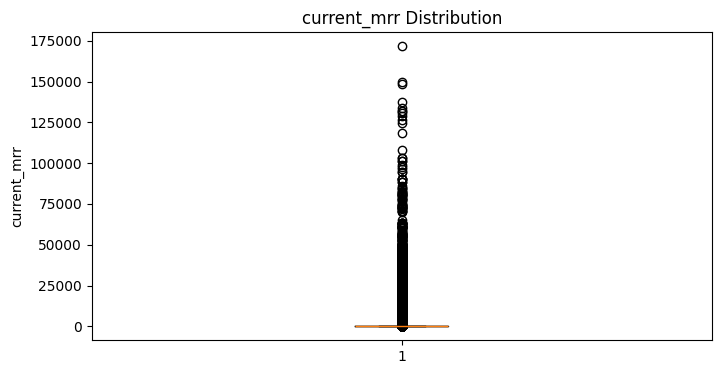

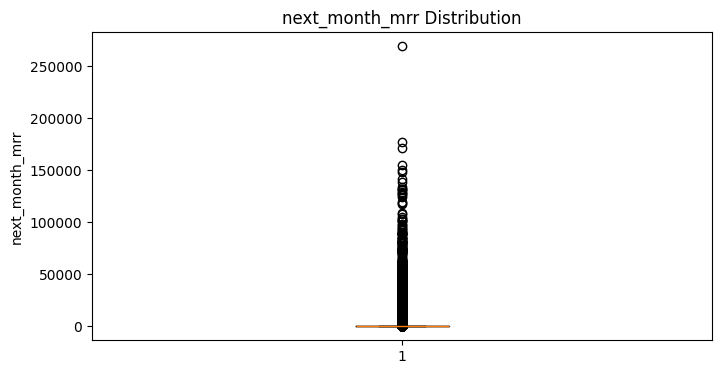

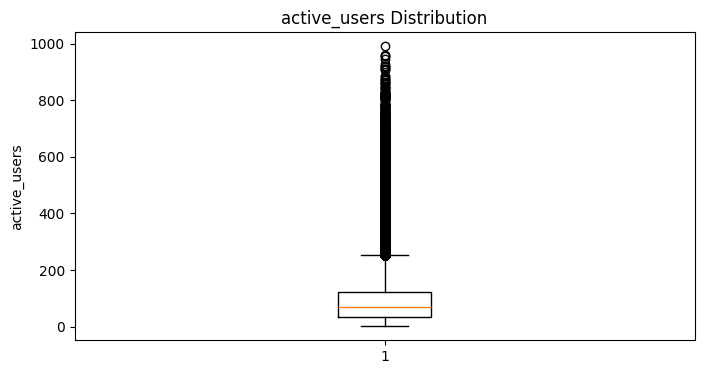

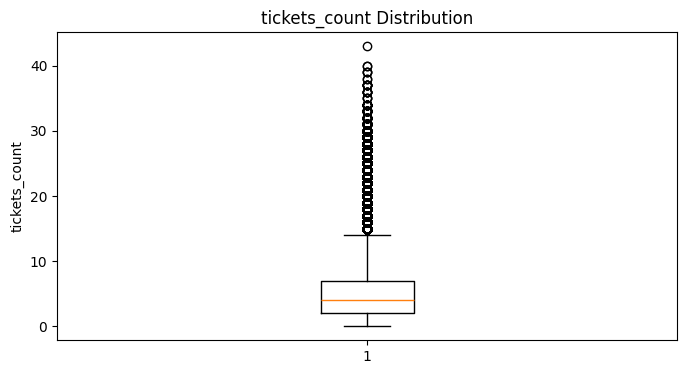

In [32]:
for col in [
    "current_mrr",
    "next_month_mrr",
    "active_users",
    "tickets_count"
]:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"{col} Distribution")
    plt.ylabel(col)
    plt.show()

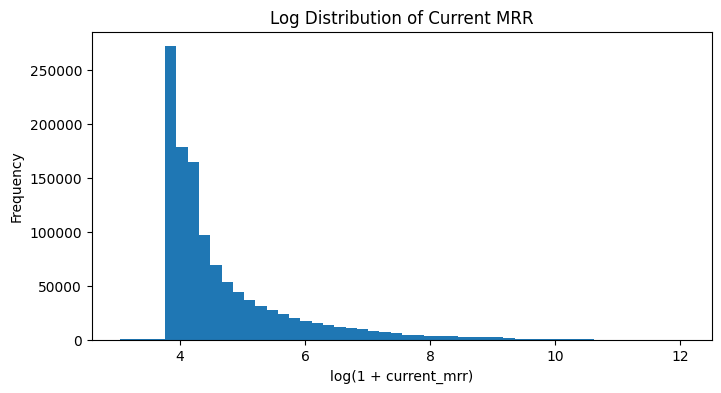

In [33]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(df["current_mrr"].dropna()), bins=50)
plt.title("Log Distribution of Current MRR")
plt.xlabel("log(1 + current_mrr)")
plt.ylabel("Frequency")
plt.show()

# Final Check

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1150000 entries, 0 to 1149999
Data columns (total 20 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   account_id                     1150000 non-null  int64  
 1   month                          1150000 non-null  int64  
 2   company_size                   1150000 non-null  str    
 3   industry                       1150000 non-null  str    
 4   contract_type                  1150000 non-null  str    
 5   discount_pct                   1150000 non-null  float64
 6   regime_state                   1150000 non-null  str    
 7   active_users                   1150000 non-null  float64
 8   usage_growth                   1150000 non-null  float64
 9   feature_adoption_rate          1150000 non-null  float64
 10  error_rate                     1150000 non-null  float64
 11  tickets_count                  1150000 non-null  float64
 12  ticket_growth            

In [35]:
df.isnull().sum().sort_values(ascending=False)

account_id                       0
month                            0
company_size                     0
industry                         0
contract_type                    0
discount_pct                     0
regime_state                     0
active_users                     0
usage_growth                     0
feature_adoption_rate            0
error_rate                       0
tickets_count                    0
ticket_growth                    0
payment_delay_flag               0
current_mrr                      0
next_month_mrr                   0
discount_pct_missing             0
feature_adoption_rate_missing    0
tickets_count_missing            0
error_rate_missing               0
dtype: int64

In [ ]:
# Split the DataFrame into chunks
chunk_size = len(df) // 2

df.iloc[:chunk_size].to_parquet("data/data_part_0.parquet", compression="gzip")
df.iloc[chunk_size:].to_parquet("data/data_part_1.parquet", compression="gzip")